<a href="https://colab.research.google.com/github/MANIKANDAN-17K/SleepApneaModel/blob/main/PatchTSTmodel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


MessageError: Error: credential propagation was unsuccessful

In [ ]:
import os
os.listdir('/content/drive/MyDrive/apnea-ecg-database-1.0.0')


['a18.apn',
 'a05.xws',
 'x26.dat',
 'c03er.xws',
 'a16.dat',
 'a02r.dat',
 'c07.apn',
 'a05.apn',
 'b04.qrs',
 'x07.hea',
 'x35.xws',
 'additional-information.txt',
 'c03.dat',
 'b04.dat',
 'c01r.hea',
 'x30.xws',
 'a07.dat',
 'c06.hea',
 'x16.qrs',
 'c02r.dat',
 'a14.xws',
 'b02.xws',
 'SHA256SUMS.txt',
 'x06.xws',
 'x18.hea',
 'a15.dat',
 'x23.xws',
 'a08.xws',
 'b02.qrs',
 'c03r.apn',
 'a06.apn',
 'x03.xws',
 'x31.dat',
 'x24.qrs',
 'a02er.hea',
 'x30.qrs',
 'x24.hea',
 'x32.xws',
 'a07.xws',
 'a05.qrs',
 'x31.xws',
 'x11.dat',
 'x28.hea',
 'x02.qrs',
 'a01er.hea',
 'b05.dat',
 'a01.xws',
 'c03.qrs',
 'b01r.apn',
 'x01.xws',
 'x23.dat',
 'a02er.qrs',
 'a07.qrs',
 'x30.dat',
 'x09.hea',
 'a13.qrs',
 'x34.dat',
 'c02r.apn',
 'a12.xws',
 'c02er.apn',
 'a13.dat',
 'c03er.apn',
 'x10.qrs',
 'c02er.xws',
 'x10.dat',
 'a03r.apn',
 'a19.qrs',
 'a16.qrs',
 'a04.xws',
 'x04.xws',
 'a08.hea',
 'a19.hea',
 'a02.dat',
 'x07.xws',
 'x26.hea',
 'c02.hea',
 'c02.xws',
 'a07.apn',
 'x22.xws',
 'b01

wfdb installation

In [ ]:
!pip install wfdb -q

# Verify
import wfdb
print(f"WFDB version: {wfdb.__version__}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 61.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.1 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.1 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.1 which is incompatible.
db-dtypes 1.5.0 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.1 which is incompatible.
WFDB version: 4.3.1


import required modules

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import Dataset, DataLoader
from scipy.signal import butter, filtfilt, iirnotch
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Check GPU
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cpu


In [ ]:
# ── Paths ──────────────────────────────────────────────────
DATA_PATH   = "/content/drive/MyDrive/apnea-ecg-database-1.0.0/"

# ── Record Groups ──────────────────────────────────────────
class_a      = [f"a{i:02d}" for i in range(1, 21)]   # a01–a20
class_b      = [f"b{i:02d}" for i in range(1, 6)]    # b01–b05
class_c      = [f"c{i:02d}" for i in range(1, 11)]   # c01–c10
test_set     = [f"x{i:02d}" for i in range(1, 36)]   # x01–x35
learning_set = class_a + class_b + class_c

print(f"Class A (Apnea)     : {len(class_a)} records")
print(f"Class B (Borderline): {len(class_b)} records")
print(f"Class C (Control)   : {len(class_c)} records")
print(f"Test Set            : {len(test_set)} records")
print(f"Total               : {len(learning_set) + len(test_set)} records")

# ── Signal Config ──────────────────────────────────────────
FS          = 100       # Sampling frequency (Hz)
WIN_SEC     = 30        # Window size in seconds
WIN_SIZE    = FS * WIN_SEC  # 3000 samples per window

# ── Training Config ────────────────────────────────────────
EPOCHS      = 50
LR          = 1e-4
BATCH_SIZE  = 32
RANDOM_SEED = 42
SAVE_PATH   = "/content/drive/MyDrive/best_model.pth"

Class A (Apnea)     : 20 records
Class B (Borderline): 5 records
Class C (Control)   : 10 records
Test Set            : 35 records
Total               : 70 records


data preprocessing ( bandpass filter, notch filtering and smoothing )

In [ ]:
def bandpass_filter(signal, fs, lowcut=0.5, highcut=40.0, order=4):
    """Remove baseline wander and high frequency noise"""
    nyq      = 0.5 * fs
    low      = lowcut / nyq
    high     = highcut / nyq
    b, a     = butter(order, [low, high], btype='band')
    filtered = filtfilt(b, a, signal)
    return filtered

def notch_filter(signal, fs, freq=50.0, quality=30.0):
    """Remove powerline interference"""
    nyq      = 0.5 * fs
    w0       = freq / nyq
    b, a     = iirnotch(w0, quality)
    filtered = filtfilt(b, a, signal)
    return filtered

def moving_average_smooth(signal, window_size=5):
    """Final smoothing"""
    kernel   = np.ones(window_size) / window_size
    smoothed = np.convolve(signal, kernel, mode='same')
    return smoothed

def preprocess_ecg(signal, fs):
    """
    Full preprocessing pipeline:
    1. Bandpass filter  (0.5–40 Hz)
    2. Notch filter     (50 Hz)
    3. Moving average smoothing
    """
    signal_bp     = bandpass_filter(signal, fs)
    signal_notch  = notch_filter(signal_bp, fs)
    signal_clean  = moving_average_smooth(signal_notch)
    return signal_clean

print("✅ Preprocessing functions ready!")

✅ Preprocessing functions ready!


── Record: a01 ──────────────────
Signal shape     : (2957000,)
Sampling rate    : 100 Hz
Duration         : 8.21 hours
Total annotations: 489
Apnea minutes    : 470
Normal minutes   : 19


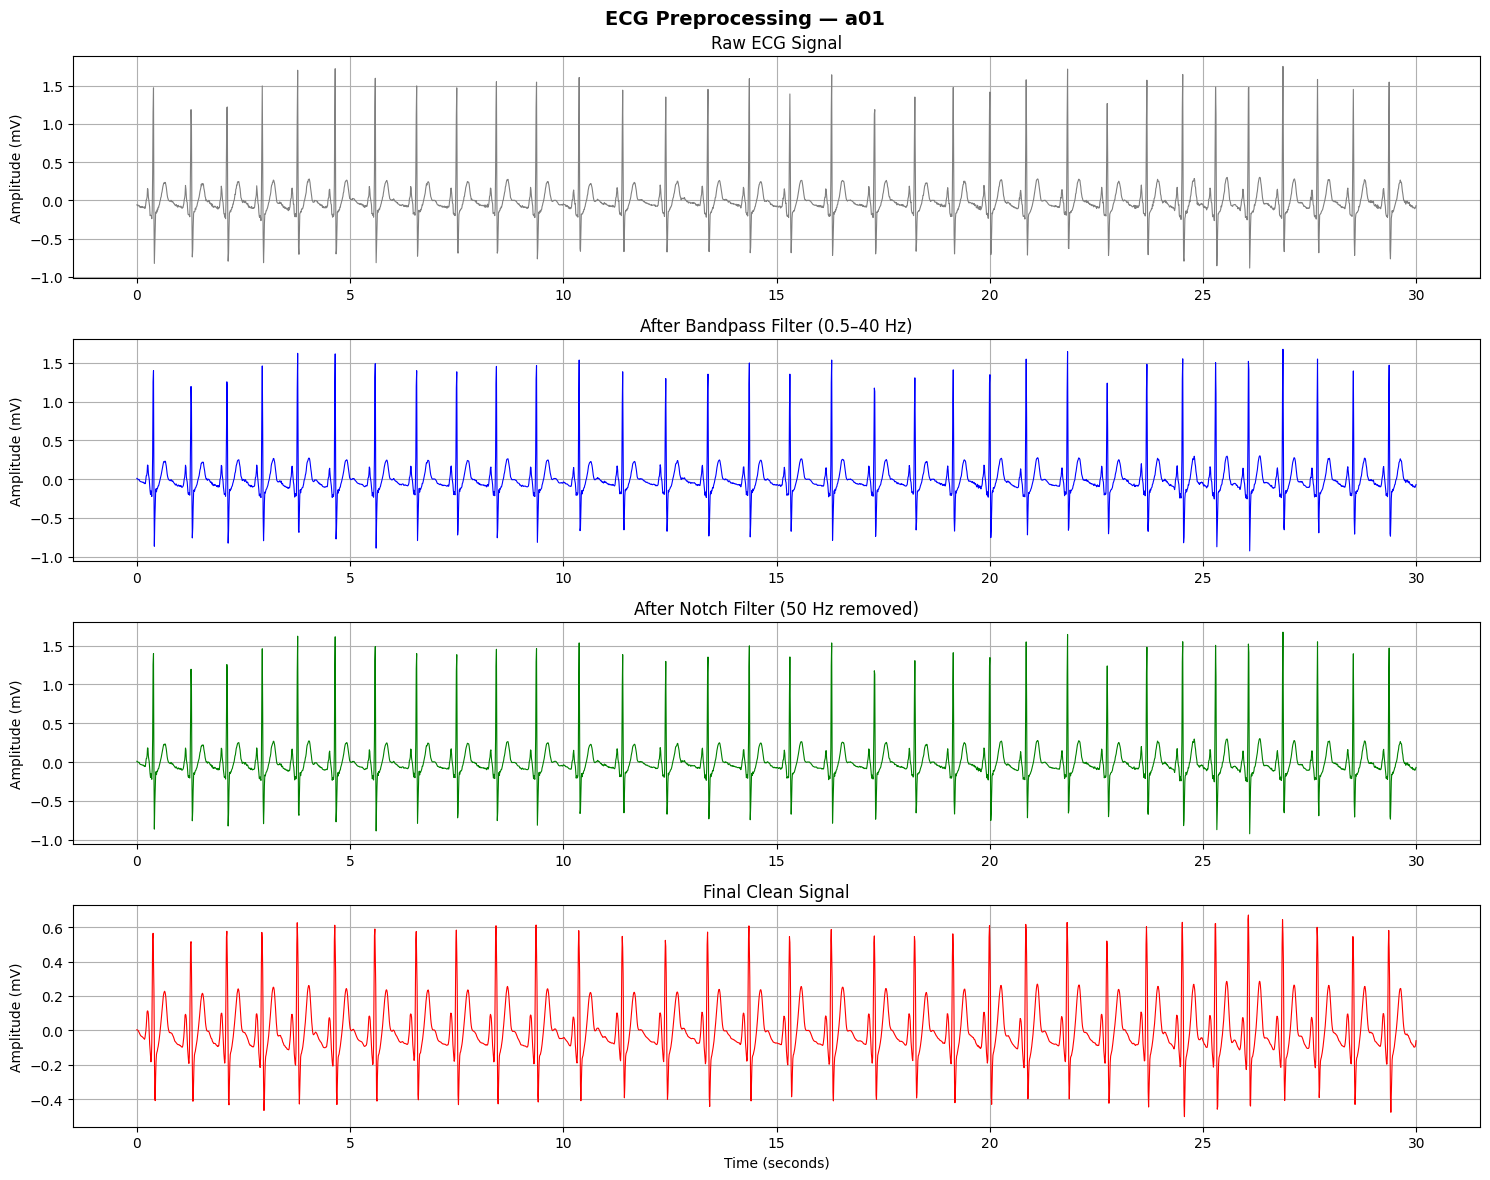

In [ ]:
def load_ecg(record_name):
    record_path = os.path.join(DATA_PATH, record_name)
    record      = wfdb.rdrecord(record_path)
    signal      = record.p_signal[:, 0]
    fs          = record.fs
    return signal, fs

def load_annotations(record_name):
    record_path = os.path.join(DATA_PATH, record_name)
    ann         = wfdb.rdann(record_path, 'apn')
    labels      = ann.symbol
    samples     = ann.sample
    return labels, samples

# Test on a01
record_name  = "a01"
signal, fs   = load_ecg(record_name)
labels, samples = load_annotations(record_name)
signal_clean = preprocess_ecg(signal, fs)

print(f"── Record: {record_name} ──────────────────")
print(f"Signal shape     : {signal.shape}")
print(f"Sampling rate    : {fs} Hz")
print(f"Duration         : {len(signal)/fs/3600:.2f} hours")
print(f"Total annotations: {len(labels)}")
print(f"Apnea minutes    : {list(labels).count('A')}")
print(f"Normal minutes   : {list(labels).count('N')}")

# Plot
time   = np.arange(3000) / fs
fig, axes = plt.subplots(4, 1, figsize=(15, 12))

axes[0].plot(time, signal[:3000],       color='gray',  linewidth=0.8)
axes[0].set_title("Raw ECG Signal")
axes[0].set_ylabel("Amplitude (mV)")
axes[0].grid(True)

signal_bp = bandpass_filter(signal, fs)
axes[1].plot(time, signal_bp[:3000],    color='blue',  linewidth=0.8)
axes[1].set_title("After Bandpass Filter (0.5–40 Hz)")
axes[1].set_ylabel("Amplitude (mV)")
axes[1].grid(True)

signal_notch = notch_filter(signal_bp, fs)
axes[2].plot(time, signal_notch[:3000], color='green', linewidth=0.8)
axes[2].set_title("After Notch Filter (50 Hz removed)")
axes[2].set_ylabel("Amplitude (mV)")
axes[2].grid(True)

axes[3].plot(time, signal_clean[:3000], color='red',   linewidth=0.8)
axes[3].set_title("Final Clean Signal")
axes[3].set_ylabel("Amplitude (mV)")
axes[3].set_xlabel("Time (seconds)")
axes[3].grid(True)

plt.suptitle(f"ECG Preprocessing — {record_name}", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

# ── Load Data ──────────────────────────────────────────────
X = np.load("/content/drive/MyDrive/X_segments.npy")
y = np.load("/content/drive/MyDrive/y_labels.npy")

print(f"Loaded X : {X.shape}")
print(f"Loaded y : {y.shape}")

# ── Config ─────────────────────────────────────────────────
LATENT_DIM   = 128
ECG_LEN      = 3000
GAN_EPOCHS   = 500
GAN_BATCH    = 64
TARGET_CLASS = 1

# ──────────────────────────────────────────────────────────
# LSTM + CNN GENERATOR
# Latent → LSTM (temporal structure) → CNN (local features)
# Output : (batch, 1, 3000)
# ──────────────────────────────────────────────────────────
class ECGGenerator(nn.Module):
    def __init__(self):
        super().__init__()

        # Step 1 — Project latent to sequence
        self.fc_in = nn.Sequential(
            nn.Linear(LATENT_DIM, 256),
            nn.ReLU()
        )

        # Step 2 — LSTM learns temporal structure
        # Input sequence: 24 timesteps of 256 features
        self.lstm = nn.LSTM(
            input_size  = 256,
            hidden_size = 256,
            num_layers  = 2,
            batch_first = True,
            dropout     = 0.2
        )

        # Step 3 — CNN upsamples to ECG length
        self.conv = nn.Sequential(
            # (batch, 256, 24)
            nn.ConvTranspose1d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            # (batch, 128, 48)

            nn.ConvTranspose1d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            # (batch, 64, 96)

            nn.ConvTranspose1d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            # (batch, 32, 192)

            nn.ConvTranspose1d(32, 16, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            # (batch, 16, 384)

            nn.ConvTranspose1d(16, 8, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm1d(8),
            nn.ReLU(),
            # (batch, 8, 768)

            nn.ConvTranspose1d(8, 1, kernel_size=4, stride=2, padding=1),
            nn.Tanh()
            # (batch, 1, 1536)
        )

        # Step 4 — Upsample to exact ECG length
        self.upsample = nn.Upsample(
            size=ECG_LEN, mode='linear', align_corners=False
        )

    def forward(self, z):
        # z : (batch, latent_dim)

        # Project to sequence
        x = self.fc_in(z)                    # (batch, 256)
        x = x.unsqueeze(1).repeat(1, 24, 1) # (batch, 24, 256)

        # LSTM — learn temporal dependencies
        x, _ = self.lstm(x)                  # (batch, 24, 256)

        # Permute for CNN
        x = x.permute(0, 2, 1)              # (batch, 256, 24)

        # CNN — upsample to ECG length
        x = self.conv(x)                     # (batch, 1, 1536)
        x = self.upsample(x)                 # (batch, 1, 3000)
        return x


# ──────────────────────────────────────────────────────────
# CNN + LSTM DISCRIMINATOR
# Input  : (batch, 1, 3000)
# Output : (batch, 1)
# ──────────────────────────────────────────────────────────
class ECGDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()

        # Step 1 — CNN extracts local features
        self.conv = nn.Sequential(
            # (batch, 1, 3000)
            nn.Conv1d(1, 16, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            # (batch, 16, 1500)

            nn.Conv1d(16, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm1d(32),
            nn.LeakyReLU(0.2),
            # (batch, 32, 750)

            nn.Conv1d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.2),
            # (batch, 64, 375)

            nn.Conv1d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2),
            # (batch, 128, 187)
        )

        # Step 2 — LSTM learns temporal patterns
        self.lstm = nn.LSTM(
            input_size  = 128,
            hidden_size = 64,
            num_layers  = 1,
            batch_first = True,
            dropout     = 0.0
        )

        # Step 3 — Classify Real/Fake
        self.fc = nn.Sequential(
            nn.Linear(64, 32),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        # x : (batch, 1, 3000)

        # CNN feature extraction
        x = self.conv(x)          # (batch, 128, 187)

        # Permute for LSTM
        x = x.permute(0, 2, 1)   # (batch, 187, 128)

        # LSTM
        x, _ = self.lstm(x)       # (batch, 187, 64)

        # Take last timestep
        x = x[:, -1, :]           # (batch, 64)

        # Classify
        return self.fc(x)         # (batch, 1)


# ── Initialize ─────────────────────────────────────────────
generator     = ECGGenerator().to(DEVICE)
discriminator = ECGDiscriminator().to(DEVICE)

g_optimizer   = torch.optim.Adam(
                    generator.parameters(),
                    lr=2e-4, betas=(0.5, 0.999))
d_optimizer   = torch.optim.Adam(
                    discriminator.parameters(),
                    lr=5e-5, betas=(0.5, 0.999))

criterion_gan = nn.BCELoss()

g_params = sum(p.numel() for p in generator.parameters())
d_params = sum(p.numel() for p in discriminator.parameters())
print(f"Generator     params: {g_params:,}")
print(f"Discriminator params: {d_params:,}")

# ── Prepare Real Apnea Samples ─────────────────────────────
apnea_indices = np.where(y == TARGET_CLASS)[0]
X_apnea       = X[apnea_indices]

X_apnea_norm  = (X_apnea - X_apnea.mean(axis=1, keepdims=True)) / \
                (X_apnea.std(axis=1, keepdims=True) + 1e-8)
X_apnea_norm  = np.clip(X_apnea_norm, -1, 1)

# Shape: (N, 1, 3000) for CNN
X_apnea_cnn   = X_apnea_norm[:, np.newaxis, :]

print(f"Real Apnea samples  : {len(X_apnea)}")
print(f"Shape for CNN+LSTM  : {X_apnea_cnn.shape}")

apnea_dataset = torch.tensor(X_apnea_cnn, dtype=torch.float32)
apnea_loader  = DataLoader(apnea_dataset, batch_size=GAN_BATCH, shuffle=True)

# ── Training Loop ──────────────────────────────────────────
print("\n" + "=" * 55)
print("  Training LSTM+CNN GAN for ECG Generation")
print("=" * 55)

g_losses = []
d_losses = []

for epoch in range(1, GAN_EPOCHS + 1):
    epoch_g_loss = 0
    epoch_d_loss = 0

    for real_ecg in apnea_loader:
        real_ecg   = real_ecg.to(DEVICE)   # (batch, 1, 3000)
        batch_size = real_ecg.size(0)

        # Label smoothing
        real_labels = torch.ones(batch_size,  1).to(DEVICE) * 0.9
        fake_labels = torch.zeros(batch_size, 1).to(DEVICE) + 0.1

        # ── Train Discriminator ONCE ──────────────────
        d_optimizer.zero_grad()
        real_output = discriminator(real_ecg)
        d_real_loss = criterion_gan(real_output, real_labels)

        z           = torch.randn(batch_size, LATENT_DIM).to(DEVICE)
        fake_ecg    = generator(z).detach()
        fake_output = discriminator(fake_ecg)
        d_fake_loss = criterion_gan(fake_output, fake_labels)

        d_loss = (d_real_loss + d_fake_loss) / 2
        d_loss.backward()
        d_optimizer.step()

        # ── Train Generator TWICE ─────────────────────
        for _ in range(2):
            g_optimizer.zero_grad()
            z           = torch.randn(batch_size, LATENT_DIM).to(DEVICE)
            fake_ecg    = generator(z)
            fake_output = discriminator(fake_ecg)
            g_loss      = criterion_gan(
                            fake_output,
                            torch.ones(batch_size, 1).to(DEVICE)
                          )
            g_loss.backward()
            g_optimizer.step()

        epoch_g_loss += g_loss.item()
        epoch_d_loss += d_loss.item()

    avg_g = epoch_g_loss / len(apnea_loader)
    avg_d = epoch_d_loss / len(apnea_loader)
    g_losses.append(avg_g)
    d_losses.append(avg_d)

    if epoch % 50 == 0:
        print(f"Epoch [{epoch:03d}/{GAN_EPOCHS}] "
              f"| G Loss: {avg_g:.4f} "
              f"| D Loss: {avg_d:.4f}")

print("\n✅ LSTM+CNN GAN Training Complete!")

# ── Plot GAN Loss ──────────────────────────────────────────
plt.figure(figsize=(10, 4))
plt.plot(g_losses, label="Generator Loss",     color="blue")
plt.plot(d_losses, label="Discriminator Loss", color="red")
plt.axhline(y=0.69, color='green', linestyle='--', label='Ideal (0.69)')
plt.title("LSTM+CNN GAN Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/gan_loss.png", dpi=150)
plt.show()

# ── Generate Synthetic Samples ─────────────────────────────
def generate_synthetic_ecg(n_samples, batch_size=256):
    generator.eval()
    all_synthetic = []
    with torch.no_grad():
        for i in range(0, n_samples, batch_size):
            n    = min(batch_size, n_samples - i)
            z    = torch.randn(n, LATENT_DIM).to(DEVICE)
            fake = generator(z).cpu().numpy()
            all_synthetic.append(fake[:, 0, :])
    return np.concatenate(all_synthetic, axis=0)

n_normal      = (y == 0).sum()
n_apnea       = (y == 1).sum()
n_to_generate = n_normal - n_apnea

print(f"\n── Balancing Dataset ────────────────────────")
print(f"Normal samples     : {n_normal}")
print(f"Apnea samples      : {n_apnea}")
print(f"To generate        : {n_to_generate}")

synthetic_ecg    = generate_synthetic_ecg(n_to_generate)
synthetic_labels = np.ones(n_to_generate, dtype=np.int64)

X_balanced = np.concatenate([X, synthetic_ecg],    axis=0)
y_balanced = np.concatenate([y, synthetic_labels], axis=0)

print(f"\n── Balanced Dataset ─────────────────────────")
print(f"Total windows      : {len(X_balanced)}")
print(f"Apnea windows      : {y_balanced.sum()}")
print(f"Normal windows     : {(y_balanced == 0).sum()}")
print(f"Apnea ratio        : {y_balanced.mean() * 100:.1f}%")

# ── Visualize Real vs Synthetic ────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(15, 6))

axes[0].plot(X_apnea[0],       color='blue', linewidth=0.8)
axes[0].set_title("Real Apnea ECG Signal")
axes[0].set_ylabel("Amplitude")
axes[0].grid(True)

axes[1].plot(synthetic_ecg[0], color='red',  linewidth=0.8)
axes[1].set_title("LSTM+CNN GAN Generated Apnea ECG Signal")
axes[1].set_ylabel("Amplitude")
axes[1].set_xlabel("Samples (3000 = 30 sec)")
axes[1].grid(True)

plt.suptitle("Real vs LSTM+CNN GAN Generated ECG",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/real_vs_synthetic.png", dpi=150)
plt.show()

# Save
np.save("/content/drive/MyDrive/X_balanced.npy", X_balanced)
np.save("/content/drive/MyDrive/y_balanced.npy", y_balanced)
print("\n✅ Saved X_balanced.npy and y_balanced.npy!")

Loaded X : (34090, 3000)
Loaded y : (34090,)
Generator     params: 1,261,065
Discriminator params: 95,537
Real Apnea samples  : 13028
Shape for CNN+LSTM  : (13028, 1, 3000)

  Training LSTM+CNN GAN for ECG Generation


In [ ]:
def segment_record(record_name):
    """Segment ECG into 30-second windows with labels"""
    signal, fs       = load_ecg(record_name)
    signal_clean     = preprocess_ecg(signal, fs)
    ann_labels, ann_samples = load_annotations(record_name)

    segments = []
    labels   = []

    for ann_sample, ann_label in zip(ann_samples, ann_labels):
        minute_start = ann_sample - (FS * 60)
        if minute_start < 0:
            minute_start = 0

        for w in range(2):
            win_start = minute_start + (w * WIN_SIZE)
            win_end   = win_start + WIN_SIZE

            if win_end > len(signal_clean):
                break

            window = signal_clean[win_start:win_end]
            label  = 1 if ann_label == 'A' else 0

            segments.append(window)
            labels.append(label)

    return np.array(segments), np.array(labels)


def build_dataset(record_list):
    """Build full dataset from record list"""
    all_segments = []
    all_labels   = []

    for record_name in record_list:
        try:
            segments, labels = segment_record(record_name)
            all_segments.append(segments)
            all_labels.append(labels)
            print(f"   {record_name} → {len(segments)} windows "
                  f"| Apnea: {labels.sum()} "
                  f"| Normal: {(labels==0).sum()}")
        except Exception as e:
            print(f"  {record_name} → Error: {e}")

    all_segments = np.concatenate(all_segments, axis=0)
    all_labels   = np.concatenate(all_labels,   axis=0)
    return all_segments, all_labels


# Build learning set
print("=" * 55)
print("  Building Dataset — Learning Set (35 records)")
print("=" * 55)

X, y = build_dataset(learning_set)

print(f"\n── Dataset Summary ──────────────────────────")
print(f"Total windows  : {len(X)}")
print(f"Apnea windows  : {y.sum()}")
print(f"Normal windows : {(y == 0).sum()}")
print(f"Apnea ratio    : {y.mean() * 100:.1f}%")
print(f"X shape        : {X.shape}")

# Save to Drive
np.save("/content/drive/MyDrive/X_segments.npy", X)
np.save("/content/drive/MyDrive/y_labels.npy",   y)
print(f"\n Saved X_segments.npy and y_labels.npy to Drive")

  Building Dataset — Learning Set (35 records)
   a01 → 978 windows | Apnea: 940 | Normal: 38
   a02 → 1056 windows | Apnea: 840 | Normal: 216
   a03 → 1038 windows | Apnea: 492 | Normal: 546
   a04 → 984 windows | Apnea: 906 | Normal: 78
   a05 → 908 windows | Apnea: 552 | Normal: 356
   a06 → 1020 windows | Apnea: 412 | Normal: 608
   a07 → 1022 windows | Apnea: 644 | Normal: 378
   a08 → 1002 windows | Apnea: 378 | Normal: 624
   a09 → 990 windows | Apnea: 762 | Normal: 228
   a10 → 1034 windows | Apnea: 200 | Normal: 834
   a11 → 932 windows | Apnea: 444 | Normal: 488
   a12 → 1154 windows | Apnea: 1068 | Normal: 86
   a13 → 990 windows | Apnea: 488 | Normal: 502
   a14 → 1018 windows | Apnea: 766 | Normal: 252
   a15 → 1020 windows | Apnea: 736 | Normal: 284
   a16 → 964 windows | Apnea: 640 | Normal: 324
   a17 → 970 windows | Apnea: 316 | Normal: 654
   a18 → 978 windows | Apnea: 876 | Normal: 102
   a19 → 1004 windows | Apnea: 410 | Normal: 594
   a20 → 1020 windows | Apnea: 63

In [ ]:
class ApneaECGDataset(Dataset):
    def __init__(self, segments, labels):
        self.X = torch.tensor(segments, dtype=torch.float32).unsqueeze(-1)
        self.y = torch.tensor(labels,   dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


def load_and_split(X, y):
    # Normalize
    X = (X - X.mean(axis=1, keepdims=True)) / (X.std(axis=1, keepdims=True) + 1e-8)

    # Train / Test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
    )
    # Train / Val split
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.1, random_state=RANDOM_SEED, stratify=y_train
    )

    print(f"Train : {X_train.shape} | Apnea: {y_train.sum()} | Normal: {(y_train==0).sum()}")
    print(f"Val   : {X_val.shape}   | Apnea: {y_val.sum()}   | Normal: {(y_val==0).sum()}")
    print(f"Test  : {X_test.shape}  | Apnea: {y_test.sum()}  | Normal: {(y_test==0).sum()}")

    # Class weights
    n_normal = (y_train == 0).sum()
    n_apnea  = (y_train == 1).sum()
    w_normal = 1.0 / n_normal
    w_apnea  = 1.0 / n_apnea
    total    = w_normal + w_apnea
    class_weights = torch.tensor(
        [w_normal / total, w_apnea / total],
        dtype=torch.float32
    )
    print(f"\nClass Weights → Normal: {class_weights[0]:.4f} | Apnea: {class_weights[1]:.4f}")

    train_loader = DataLoader(ApneaECGDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
    val_loader   = DataLoader(ApneaECGDataset(X_val,   y_val),   batch_size=BATCH_SIZE, shuffle=False)
    test_loader  = DataLoader(ApneaECGDataset(X_test,  y_test),  batch_size=BATCH_SIZE, shuffle=False)

    return train_loader, val_loader, test_loader, class_weights


train_loader, val_loader, test_loader, class_weights = load_and_split(X, y)

X_batch, y_batch = next(iter(train_loader))
print(f"\nSample batch → X: {X_batch.shape} | y: {y_batch.shape}")
print("✅ DataLoaders ready!")

Train : (24544, 3000) | Apnea: 9379 | Normal: 15165
Val   : (2728, 3000)   | Apnea: 1043   | Normal: 1685
Test  : (6818, 3000)  | Apnea: 2606  | Normal: 4212

Class Weights → Normal: 0.3821 | Apnea: 0.6179

Sample batch → X: torch.Size([32, 3000, 1]) | y: torch.Size([32])
✅ DataLoaders ready!


In [ ]:
class PatchTSTConfig:
    seq_len   = 3000
    n_vars    = 1
    patch_len = 50
    stride    = 25
    d_model   = 128
    n_heads   = 8
    n_layers  = 4
    d_ff      = 256
    dropout   = 0.1
    n_classes = 2

    @property
    def n_patches(self):
        return (self.seq_len - self.patch_len) // self.stride + 1


class PatchEmbedding(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.patch_len  = cfg.patch_len
        self.stride     = cfg.stride
        self.projection = nn.Linear(cfg.patch_len, cfg.d_model)
        self.norm       = nn.LayerNorm(cfg.d_model)
        self.dropout    = nn.Dropout(cfg.dropout)

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = x.unfold(dimension=-1, size=self.patch_len, step=self.stride)
        x = x.squeeze(1)
        x = self.projection(x)
        x = self.norm(x)
        return self.dropout(x)


class PositionalEncoding(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.pos_embedding = nn.Parameter(
            torch.randn(1, cfg.n_patches, cfg.d_model)
        )
        self.dropout = nn.Dropout(cfg.dropout)

    def forward(self, x):
        return self.dropout(x + self.pos_embedding)


class TransformerEncoderBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.attention = nn.MultiheadAttention(
            embed_dim=cfg.d_model, num_heads=cfg.n_heads,
            dropout=cfg.dropout, batch_first=True
        )
        self.ffn = nn.Sequential(
            nn.Linear(cfg.d_model, cfg.d_ff),
            nn.GELU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(cfg.d_ff, cfg.d_model),
            nn.Dropout(cfg.dropout)
        )
        self.norm1 = nn.LayerNorm(cfg.d_model)
        self.norm2 = nn.LayerNorm(cfg.d_model)

    def forward(self, x):
        attn_out, _ = self.attention(x, x, x)
        x = self.norm1(x + attn_out)
        return self.norm2(x + self.ffn(x))


class PatchTST(nn.Module):
    def __init__(self, cfg=None):
        super().__init__()
        if cfg is None:
            cfg = PatchTSTConfig()
        self.patch_embedding = PatchEmbedding(cfg)
        self.pos_encoding    = PositionalEncoding(cfg)
        self.encoder_layers  = nn.ModuleList([
            TransformerEncoderBlock(cfg) for _ in range(cfg.n_layers)
        ])
        self.classifier = nn.Sequential(
            nn.Linear(cfg.d_model, cfg.d_model // 2),
            nn.GELU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(cfg.d_model // 2, cfg.n_classes)
        )

    def forward(self, x):
        x = self.patch_embedding(x)
        x = self.pos_encoding(x)
        for layer in self.encoder_layers:
            x = layer(x)
        x = x.mean(dim=1)
        return self.classifier(x)


# Initialize model
cfg   = PatchTSTConfig()
model = PatchTST(cfg).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters : {total_params:,}")

dummy = torch.randn(32, 3000, 1).to(DEVICE)
out   = model(dummy)
print(f"Input  shape     : {dummy.shape}")
print(f"Output shape     : {out.shape}")
print("✅ PatchTST Model ready!")

Total parameters : 560,322
Input  shape     : torch.Size([32, 3000, 1])
Output shape     : torch.Size([32, 2])
✅ PatchTST Model ready!


In [ ]:
criterion = nn.CrossEntropyLoss(weight=class_weights.to(DEVICE))
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)


def train_epoch(model, loader):
    model.train()
    total_loss, all_preds, all_labels = 0, [], []
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss    = criterion(outputs, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
        all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())
    avg_loss = total_loss / len(loader)
    acc      = accuracy_score(all_labels, all_preds)
    f1       = f1_score(all_labels, all_preds, average='macro')
    return avg_loss, acc, f1


def val_epoch(model, loader):
    model.eval()
    total_loss, all_preds, all_labels = 0, [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            outputs    = model(X_batch)
            loss       = criterion(outputs, y_batch)
            total_loss += loss.item()
            all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())
    avg_loss = total_loss / len(loader)
    acc      = accuracy_score(all_labels, all_preds)
    f1       = f1_score(all_labels, all_preds, average='macro')
    return avg_loss, acc, f1


# Training Loop
print("=" * 60)
print("  Training PatchTST Model")
print("=" * 60)

history      = {"train_loss": [], "val_loss": [],
                "train_acc" : [], "val_acc" : [],
                "train_f1"  : [], "val_f1"  : []}
best_val_f1  = 0.0
best_epoch   = 0

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc, train_f1 = train_epoch(model, train_loader)
    val_loss,   val_acc,   val_f1   = val_epoch(model,   val_loader)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["train_f1"].append(train_f1)
    history["val_f1"].append(val_f1)

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_epoch  = epoch
        torch.save(model.state_dict(), SAVE_PATH)
        saved = "Saved"
    else:
        saved = ""

    print(f"Epoch [{epoch:02d}/{EPOCHS}] "
          f"| Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} F1: {train_f1:.4f} "
          f"| Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} F1: {val_f1:.4f} "
          f"{saved}")

print(f"\nBest model → Epoch {best_epoch} | Val F1: {best_val_f1:.4f}")

  Training PatchTST Model
Epoch [01/50] | Train Loss: 0.5500 Acc: 0.7075 F1: 0.7001 | Val Loss: 0.4442 Acc: 0.7980 F1: 0.7923 Saved
Epoch [02/50] | Train Loss: 0.4337 Acc: 0.7993 F1: 0.7937 | Val Loss: 0.3989 Acc: 0.8204 F1: 0.8159 Saved
Epoch [03/50] | Train Loss: 0.3877 Acc: 0.8193 F1: 0.8148 | Val Loss: 0.3955 Acc: 0.8299 F1: 0.8237 Saved
Epoch [04/50] | Train Loss: 0.3591 Acc: 0.8314 F1: 0.8273 | Val Loss: 0.3426 Acc: 0.8314 F1: 0.8283 Saved
Epoch [05/50] | Train Loss: 0.3382 Acc: 0.8406 F1: 0.8364 | Val Loss: 0.3377 Acc: 0.8310 F1: 0.8285 Saved
Epoch [06/50] | Train Loss: 0.3166 Acc: 0.8530 F1: 0.8489 | Val Loss: 0.3315 Acc: 0.8321 F1: 0.8298 Saved
Epoch [07/50] | Train Loss: 0.3042 Acc: 0.8584 F1: 0.8542 | Val Loss: 0.3260 Acc: 0.8479 F1: 0.8439 Saved
Epoch [08/50] | Train Loss: 0.2906 Acc: 0.8684 F1: 0.8640 | Val Loss: 0.3176 Acc: 0.8684 F1: 0.8631 Saved
Epoch [09/50] | Train Loss: 0.2757 Acc: 0.8776 F1: 0.8731 | Val Loss: 0.3098 Acc: 0.8589 F1: 0.8556 
Epoch [10/50] | Train Los

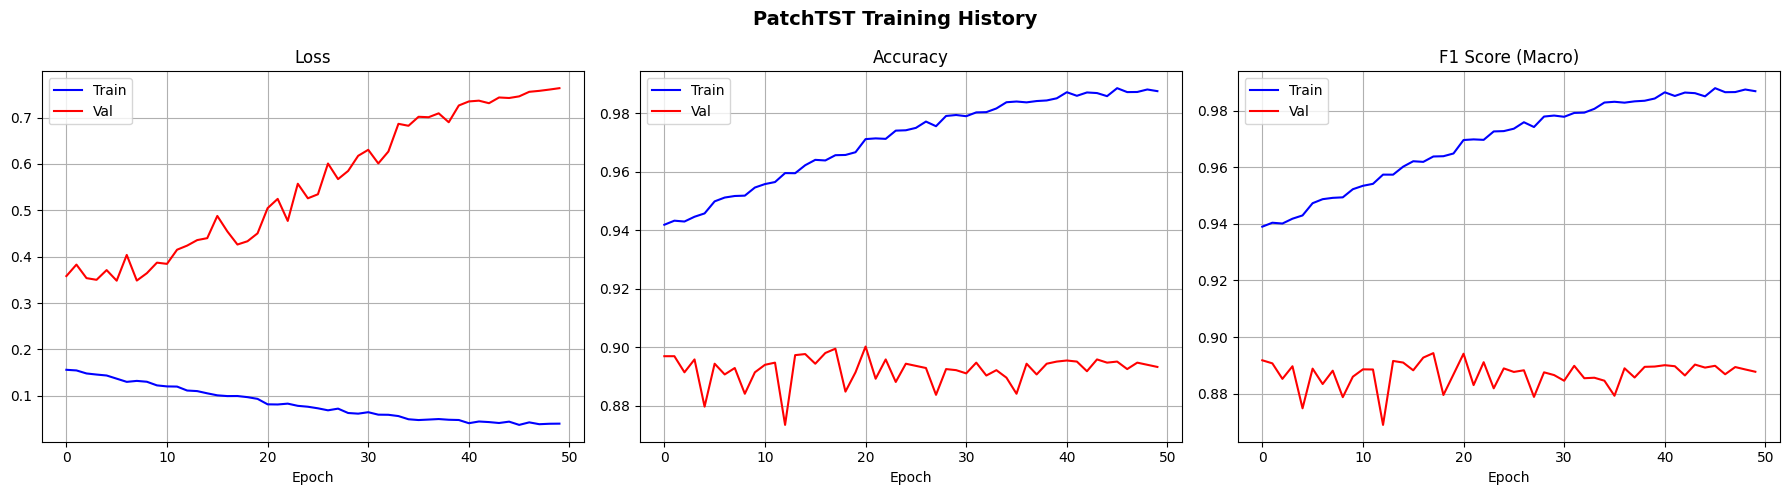


  Final Evaluation on Test Set
              precision    recall  f1-score   support

      Normal       0.92      0.90      0.91      4212
       Apnea       0.85      0.87      0.86      2606

    accuracy                           0.89      6818
   macro avg       0.88      0.89      0.89      6818
weighted avg       0.89      0.89      0.89      6818

 Saved predictions to Drive!


In [ ]:
# Plot Training History
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history["train_loss"], label="Train", color="blue")
axes[0].plot(history["val_loss"],   label="Val",   color="red")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history["train_acc"], label="Train", color="blue")
axes[1].plot(history["val_acc"],   label="Val",   color="red")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(True)

axes[2].plot(history["train_f1"], label="Train", color="blue")
axes[2].plot(history["val_f1"],   label="Val",   color="red")
axes[2].set_title("F1 Score (Macro)")
axes[2].set_xlabel("Epoch")
axes[2].legend()
axes[2].grid(True)

plt.suptitle("PatchTST Training History", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/training_history.png", dpi=150)
plt.show()

# Final Evaluation
print("\n" + "=" * 60)
print("  Final Evaluation on Test Set")
print("=" * 60)

model.load_state_dict(torch.load(SAVE_PATH))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        outputs = model(X_batch)
        all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
        all_labels.extend(y_batch.numpy())

print(classification_report(all_labels, all_preds, target_names=["Normal", "Apnea"]))

np.save("/content/drive/MyDrive/test_preds.npy",  np.array(all_preds))
np.save("/content/drive/MyDrive/test_labels.npy", np.array(all_labels))
print(" Saved predictions to Drive!")